In [37]:
import requests
import matplotlib.pyplot as plt

In [2]:
query = {
    "query": {
        "type": "group",
        "logical_operator": "and",
        "nodes": [{
            "type": "terminal",
            "service": "text",
            "parameters": {
                "attribute": "rcsb_accession_info.deposit_date",
                "operator": "greater",
                "value": "2021-09-30"
            }
        }]
    },
    "return_type": "entry",
    "request_options": {
        "results_verbosity": "minimal",
        "paginate": {"start": 0, "rows": 1000}
    }
}

In [3]:
response = requests.post(
    "https://search.rcsb.org/rcsbsearch/v2/query",
    json=query
)
results = response.json()
results['total_count']

59516

In [4]:
nodes = [
    # Post-training cutoff
    {
        "type": "terminal",
        "service": "text",
        "parameters": {
            "attribute": "rcsb_accession_info.deposit_date",
            "operator": "greater",
            "value": "2021-09-30"
        }
    } ,
    # X-ray only
    {
        "type": "terminal",
        "service": "text",
        "parameters": {
            "attribute": "exptl.method",
            "operator": "exact_match",
            "value": "X-RAY DIFFRACTION"
        }
    },
    # Resolution <= 2.5 Angstrom
    {
        "type": "terminal",
        "service": "text",
        "parameters": {
            "attribute": "rcsb_entry_info.resolution_combined",
            "operator": "less_or_equal",
            "value": 2.5
        }
    },
    # Only one polymer entity (restrict to monomers):
    {
        "type": "terminal",
        "service": "text",
        "parameters": {
            "attribute": "rcsb_entry_info.deposited_polymer_entity_instance_count",
            "operator": "equals",
            "value": 1
        }
    },
    # Protein only (no DNA/RNA)
    {
        "type": "terminal",
        "service": "text",
        "parameters": {
            "attribute": "rcsb_entry_info.selected_polymer_entity_types",
            "operator": "exact_match",
            "value": "Protein (only)"
        }
    },
    # No small molecule ligands
    {
        "type": "terminal",
        "service": "text",
        "parameters": {
            "attribute": "rcsb_entry_info.nonpolymer_entity_count",
            "operator": "equals",
            "value": 0
        }
    },
    # Only monomers
]

In [5]:
query['query']['nodes'] = nodes
query['request_options']['paginate'] = {"start": 0, "rows": 1500}

In [6]:
response = requests.post(
    "https://search.rcsb.org/rcsbsearch/v2/query",
    json=query
)
results = response.json()
results['total_count']

1311

In [ ]:
pdb_ids = [entry['identifier'] for entry in results['result_set']]


1311

In [11]:
url = "https://cdn.rcsb.org/resources/sequence/clusters/clusters-by-entity-30.txt"
cluster_text = requests.get(url).text

In [16]:
# Build mapping: entity_id -> cluster_id
entity_to_cluster = {}
for cluster_id, line in enumerate(cluster_text.strip().split("\n")):
    for entity_id in line.strip().split():
        entity_to_cluster[entity_id] = cluster_id

In [24]:
# For single-entity entries, entity ID is always PDBID_1
pdb_to_cluster = {}
for pdb_id in pdb_ids:
    entity_id = f"{pdb_id}_1"
    if entity_id in entity_to_cluster:
        pdb_to_cluster[pdb_id] = entity_to_cluster[entity_id]

In [26]:
len(pdb_to_cluster)

1297

In [27]:
import random
from collections import defaultdict

# Group PDB IDs by cluster
cluster_to_pdbs = defaultdict(list)
for pdb_id, cluster_id in pdb_to_cluster.items():
    cluster_to_pdbs[cluster_id].append(pdb_id)

print(f"Unique clusters: {len(cluster_to_pdbs)}")

# Pick one representative per cluster (random)
random.seed(42)
representatives = [random.choice(pdbs) for pdbs in cluster_to_pdbs.values()]
print(f"Representatives: {len(representatives)}")

Unique clusters: 620
Representatives: 620


In [58]:
def fetch_sequences(pdb_ids):
    url = "https://data.rcsb.org/graphql"
    
    query = """
    query($ids: [String!]!) {
        entries(entry_ids: $ids) {
            rcsb_id
            polymer_entities {
                entity_poly {
                    pdbx_seq_one_letter_code_can
                }
            }
        }
    }
    """
    
    response = requests.post(url, json={
        "query": query,
        "variables": {"ids": pdb_ids}
    })
    
    lengths, sequences = {}, {}
    for entry in response.json()["data"]["entries"]:
        pdb_id = entry["rcsb_id"]
        seq = entry["polymer_entities"][0]["entity_poly"]["pdbx_seq_one_letter_code_can"]
        sequences[pdb_id] = seq
        lengths[pdb_id] = len(seq)
    
    return lengths, sequences

In [62]:
# Fetch lengths for all 620 representatives
all_lengths, all_sequences = fetch_sequences(representatives)

# Filter to 50-500
filtered_reps = [pdb_id for pdb_id in representatives 
                 if 50 <= all_lengths[pdb_id] <= 500]

print(f"Filtered representatives: {len(filtered_reps)}")

# Re-sample 100
random.seed(42)
validation_set = random.sample(filtered_reps, 100)

lengths = {pdb_id: all_lengths[pdb_id] for pdb_id in validation_set}
sequences = {pdb_id: all_sequences[pdb_id] for pdb_id in validation_set}

Filtered representatives: 563


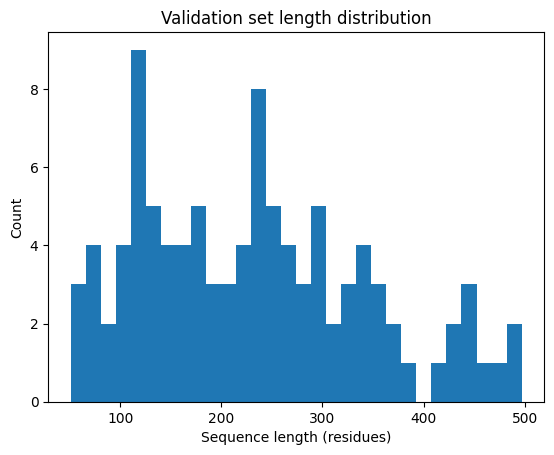

Min: 51, Max: 497, Median: 231


In [63]:
vals = list(lengths.values())
plt.hist(vals, bins=30)
plt.xlabel("Sequence length (residues)")
plt.ylabel("Count")
plt.title("Validation set length distribution")
plt.show()

print(f"Min: {min(vals)}, Max: {max(vals)}, Median: {sorted(vals)[len(vals)//2]}")

In [65]:
with open("protein_validation_set.fasta", "w") as f:
    for pdb_id, seq in sequences.items():
        f.write(f">{pdb_id}\n{seq}\n")